In [1]:
import torch
from torch.utils.data import Dataset, DataLoader

class NeedleDataset(Dataset):
    def __init__(self, seq_len, vocab_size=50, n_samples=1000):
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        self.n_samples = n_samples

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        seq = torch.randint(2, self.vocab_size, (self.seq_len,))
        needle_pos = torch.randint(0, self.seq_len, (1,)).item()
        seq[needle_pos] = 1

        # Binary label: 0 = first half, 1 = second half
        label = 1 if needle_pos >= self.seq_len // 2 else 0
        return seq, label

    

In [2]:
import torch

# Set device globally
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.cuda.empty_cache()


Using device: cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Ti SUPER


In [3]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, vocab_size=50, embed_dim=64, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)  # binary: needle in first or second half

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # take last hidden state
        return self.fc(out)

In [4]:
class TransformerModel(nn.Module):
    def __init__(self, vocab_size=50, embed_dim=64, nhead=4, num_layers=2, seq_len=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoding = nn.Embedding(seq_len, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead, dim_feedforward=256,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, 2)  # binary: needle in first or second half

    def forward(self, x):
        # Ensure positions tensor is on the same device as input
        positions = torch.arange(x.size(1), device=x.device, dtype=torch.long).unsqueeze(0)
        x = self.embedding(x) + self.pos_encoding(positions)
        out = self.transformer(x)
        out = out.mean(dim=1)  # pool over sequence
        return self.fc(out)

In [5]:
import time
import torch

def train(model, seq_len, epochs=10, batch_size=32):
    dataset = NeedleDataset(seq_len=seq_len)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # Use the global device variable
    model.to(device)

    # Track metrics per epoch
    history = {
        "accuracy": [],
        "loss": [],
        "time": [],
        "memory_mb": []
    }

    for epoch in range(epochs):
        total_loss, correct = 0, 0
        start = time.time()
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

        for seqs, labels in loader:
            seqs, labels = seqs.to(device), labels.to(device)
            optimizer.zero_grad()
            output = model(seqs)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (output.argmax(dim=1) == labels).sum().item()

        acc = correct / len(dataset)
        elapsed = time.time() - start
        mem = torch.cuda.max_memory_allocated() / 1e6 if torch.cuda.is_available() else 0

        history["accuracy"].append(acc)
        history["loss"].append(total_loss)
        history["time"].append(elapsed)
        history["memory_mb"].append(mem)

        print(f"Epoch {epoch+1} | Loss: {total_loss:.3f} | Acc: {acc:.3f} | Time: {elapsed:.1f}s | Mem: {mem:.1f}MB")

    return history


In [6]:
results = {}  # master dictionary

seq_lengths = [32, 64, 128, 256, 512, 1024]

# More epochs for longer sequences since the task is harder
epoch_schedule = {32: 15, 64: 20, 128: 25, 256: 30, 512: 35, 1024: 20}

print(f"\n{'='*60}")
print(f"Training Models on {device}")
print(f"{'='*60}\n")

for seq_len in seq_lengths:
    print(f"\n{'='*40}")
    print(f"Sequence Length: {seq_len}")
    print(f"{'='*40}")
    epochs = epoch_schedule[seq_len]

    print(f"\nTraining LSTM ({epochs} epochs)...")
    lstm = LSTMModel().to(device)
    results[f"lstm_{seq_len}"] = train(lstm, seq_len=seq_len, epochs=epochs)

    print(f"\nTraining Transformer ({epochs} epochs)...")
    transformer = TransformerModel(seq_len=seq_len).to(device)
    results[f"transformer_{seq_len}"] = train(transformer, seq_len=seq_len, epochs=epochs)



Training Models on cuda


Sequence Length: 32

Training LSTM (15 epochs)...
Epoch 1 | Loss: 21.181 | Acc: 0.587 | Time: 0.2s | Mem: 44.3MB
Epoch 2 | Loss: 12.799 | Acc: 0.827 | Time: 0.0s | Mem: 44.3MB
Epoch 3 | Loss: 3.142 | Acc: 0.960 | Time: 0.1s | Mem: 44.3MB
Epoch 4 | Loss: 2.190 | Acc: 0.970 | Time: 0.1s | Mem: 44.3MB
Epoch 5 | Loss: 1.640 | Acc: 0.981 | Time: 0.1s | Mem: 44.3MB
Epoch 6 | Loss: 1.643 | Acc: 0.982 | Time: 0.0s | Mem: 44.3MB
Epoch 7 | Loss: 1.724 | Acc: 0.977 | Time: 0.1s | Mem: 44.3MB
Epoch 8 | Loss: 1.715 | Acc: 0.976 | Time: 0.1s | Mem: 44.3MB
Epoch 9 | Loss: 1.802 | Acc: 0.976 | Time: 0.1s | Mem: 44.3MB
Epoch 10 | Loss: 1.445 | Acc: 0.978 | Time: 0.1s | Mem: 44.3MB
Epoch 11 | Loss: 1.050 | Acc: 0.987 | Time: 0.0s | Mem: 44.3MB
Epoch 12 | Loss: 1.503 | Acc: 0.980 | Time: 0.1s | Mem: 44.3MB
Epoch 13 | Loss: 2.741 | Acc: 0.963 | Time: 0.1s | Mem: 44.3MB
Epoch 14 | Loss: 1.712 | Acc: 0.977 | Time: 0.1s | Mem: 44.3MB
Epoch 15 | Loss: 1.532 | Acc: 0.979 | Time: 0.0s

In [7]:
import json

# Save results
with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Results saved to results.json")

# Load them back anytime
with open("results.json", "r") as f:
    results = json.load(f)

Results saved to results.json


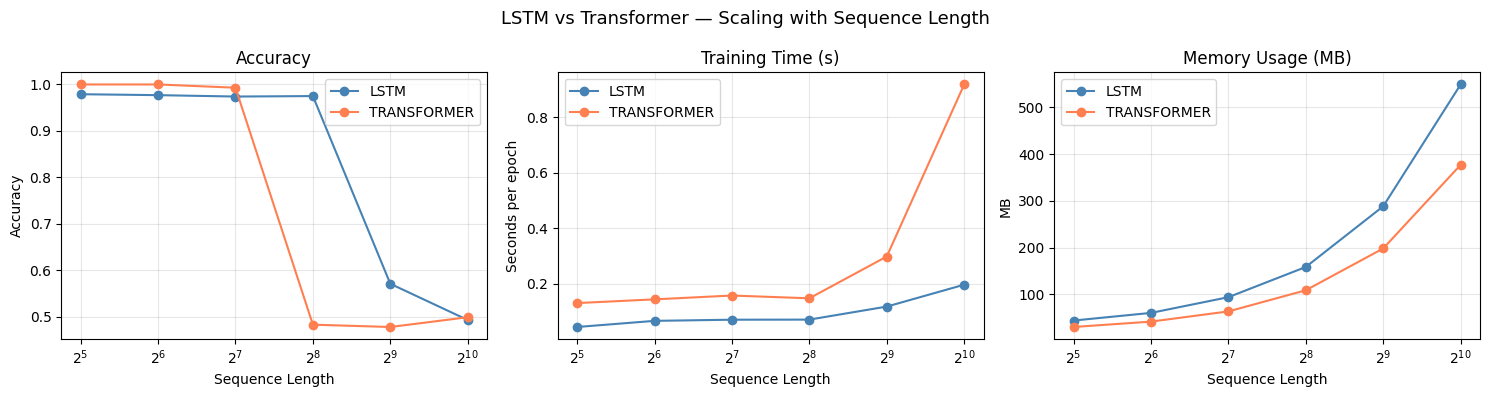

Plot saved as results_plot.png


In [9]:
import matplotlib.pyplot as plt

seq_lengths = [32, 64, 128, 256, 512, 1024]
models = ["lstm", "transformer"]
colors = {"lstm": "steelblue", "transformer": "coral"}

def get_final(metric, model_name):
    # Get the last epoch value for each sequence length
    return [results[f"{model_name}_{s}"][metric][-1] for s in seq_lengths]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("LSTM vs Transformer — Scaling with Sequence Length", fontsize=13)

# Plot 1: Accuracy
ax = axes[0]
for m in models:
    ax.plot(seq_lengths, get_final("accuracy", m),
            marker="o", label=m.upper(), color=colors[m])
ax.set_title("Accuracy")
ax.set_xlabel("Sequence Length")
ax.set_ylabel("Accuracy")
ax.set_xscale("log", base=2)  # log scale since lengths double
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Training Time
ax = axes[1]
for m in models:
    ax.plot(seq_lengths, get_final("time", m),
            marker="o", label=m.upper(), color=colors[m])
ax.set_title("Training Time (s)")
ax.set_xlabel("Sequence Length")
ax.set_ylabel("Seconds per epoch")
ax.set_xscale("log", base=2)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Memory Usage
ax = axes[2]
for m in models:
    ax.plot(seq_lengths, get_final("memory_mb", m),
            marker="o", label=m.upper(), color=colors[m])
ax.set_title("Memory Usage (MB)")
ax.set_xlabel("Sequence Length")
ax.set_ylabel("MB")
ax.set_xscale("log", base=2)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as results_plot.png")